CUSTOMER SEGMENTATION ANALYSIS

First 5 Records:
  Customer_ID  Age  Annual_Income  Spending_Score
0        C001   22          25000              85
1        C002   25          30000              90
2        C003   28          35000              75
3        C004   35          50000              60
4        C005   40          55000              55

Dataset Shape:
(20, 4)

Column Names:
['Customer_ID', 'Age', 'Annual_Income', 'Spending_Score']

Data Types:
Customer_ID         str
Age               int64
Annual_Income     int64
Spending_Score    int64
dtype: object

Missing Values:
Customer_ID       0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Descriptive Statistics:
             Age  Annual_Income  Spending_Score
count  20.000000      20.000000       20.000000
mean   36.400000   48400.000000       60.900000
std    10.414565   15968.389828       20.419031
min    22.000000   25000.000000       30.000000
25%    27.750000   34500.000000       44.250000
50%    3

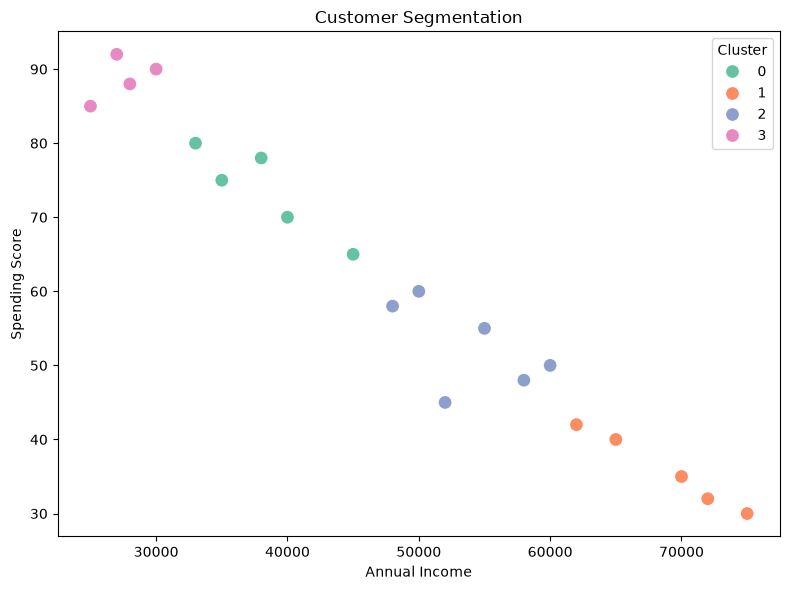

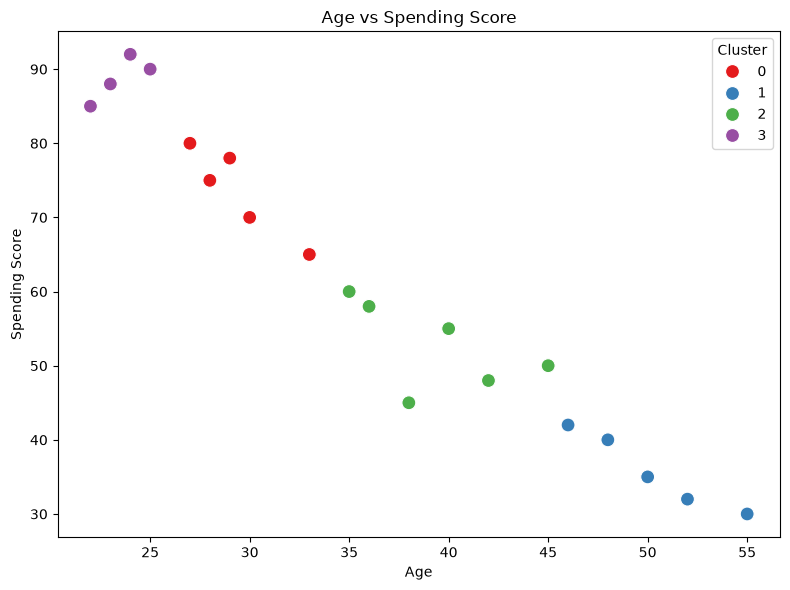

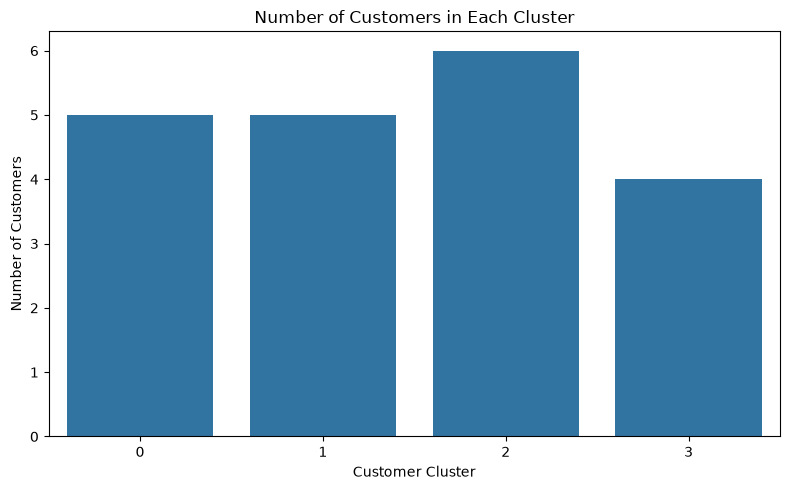


Segmented dataset saved successfully!

CONCLUSION

K-Means clustering was used to segment customers
based on Age, Annual Income and Spending Score.

The customers were divided into four different
groups based on their characteristics.

Customer segmentation helps businesses understand
customer behaviour and create targeted marketing
strategies.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load customer dataset
df = pd.read_csv("customer.csv")

print("CUSTOMER SEGMENTATION ANALYSIS")
print("=" * 40)

# Display first 5 rows
print("\nFirst 5 Records:")
print(df.head())


# Dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())


# Select features for clustering
X = df[[
    "Age",
    "Annual_Income",
    "Spending_Score"
]]


# Standardize the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)


# Display customer segments
print("\nCustomer Segments:")
print(
    df[
        [
            "Customer_ID",
            "Age",
            "Annual_Income",
            "Spending_Score",
            "Cluster"
        ]
    ]
)


# Cluster summary
print("\nCluster Summary:")

cluster_summary = df.groupby("Cluster")[
    [
        "Age",
        "Annual_Income",
        "Spending_Score"
    ]
].mean()

print(cluster_summary)


# Number of customers in each cluster
print("\nNumber of Customers in Each Cluster:")

cluster_count = df["Cluster"].value_counts().sort_index()

print(cluster_count)


# Visualization 1
# Annual Income vs Spending Score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set2",
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.tight_layout()
plt.show()


# Visualization 2
# Age vs Spending Score

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending_Score",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.tight_layout()
plt.show()


# Visualization 3
# Number of customers in each cluster

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# Save the segmented dataset

df.to_csv(
    "customer_segmented_dataset.csv",
    index=False
)

print("\nSegmented dataset saved successfully!")


# Final conclusion

print("""
CONCLUSION

K-Means clustering was used to segment customers
based on Age, Annual Income and Spending Score.

The customers were divided into four different
groups based on their characteristics.

Customer segmentation helps businesses understand
customer behaviour and create targeted marketing
strategies.
""")